# HMM市场状态预测

## 日线数据处理

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/kline_im.csv')
# datetime设为索引
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
# 重采样聚合 (关键步骤：不同维度处理方式不同)
daily_df = df.resample('D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'vol': 'sum',
    'rsrs': 'mean'  # 衍生指标取日内平均值
}).dropna()  # 剔除无交易的周末和假期
daily_df
# 日线数据
daily_df.to_csv("../data/kline_im_daily.csv", index=True, encoding='utf-8')
# 假设你的数据变量名为 raw_data
# final_matrix, debug_df = process_to_daily_features(raw_data)
# print(final_matrix.head(10))

## 特征处理

In [133]:
df_day = pd.read_csv("../data/kline_im_daily.csv")
df_day.set_index('DateTime', inplace=True)
# 一日对数成交量差
df_day['f1'] = np.log(df_day['vol']) - np.log(df_day['vol'].shift(1))

# 五日对数成交量差
df_day['f2'] = np.log(df_day['vol']) - np.log(df_day['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_day['f3'] = np.log(df_day['close']) - np.log(df_day['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_day['f4'] = np.log(df_day['close']) - np.log(df_day['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_day['f5'] = np.log(df_day['high']) - np.log(df_day['low'])
# 删除前五行数据（滑窗）
df_day = df_day.drop(df_day.index[:5])
# 训练验证集和测试集划分
df_day

,open,high,low,close,vol,rsrs,f1,f2,f3,f4,f5
DateTime,,,,,,,,,,,
2022-07-29,5121.799985,5143.799985,5059.799985,5078.799985,25025,0.912904,0.107961,0.121902,-0.006281,0.026011,0.016465
2022-08-01,5061.999985,5132.799985,4996.199985,5128.399985,22084,0.938142,-0.125022,-0.035541,0.009719,0.051618,0.026974
2022-08-02,5061.799985,5066.799985,4812.199985,4939.999985,37753,0.866238,0.536212,0.672567,-0.037428,-0.008627,0.051555
2022-08-03,4981.799985,5053.799985,4852.599985,4874.599985,32325,0.808511,-0.155224,0.516254,-0.013327,-0.036933,0.040626
2022-08-04,4924.799985,4934.599985,4769.999985,4882.599985,35394,0.978184,0.090701,0.454628,0.001640,-0.045678,0.033925
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,7963.800000,7974.400000,7814.000000,7952.800000,66103,0.894445,0.166452,-0.933375,0.000201,-0.000503,0.020319
2026-03-17,7970.000000,7988.800000,7760.800000,7770.800000,78237,0.864864,0.168529,-0.330173,-0.023151,-0.038944,0.028955
2026-03-18,7815.000000,7874.000000,7740.200000,7844.600000,92768,0.918249,0.170359,0.034568,0.009452,-0.029418,0.017139


## 滚动窗口标准化

In [134]:
window = 252
features = ["f1", "f2", "f3", "f4", "f5"]
# 计算滚动均值和滚动标准差
rolling_mean = df_day[features].rolling(window=window).mean()
rolling_std = df_day[features].rolling(window=window).std()


# 执行滚动标准化
# 前 251 行会因为窗口不足产生 NaN
df_feature_rolling = (df_day[features] - rolling_mean) / rolling_std
df_train_norm = df_feature_rolling.loc['2022-07-29':'2024-09-30'].dropna()
df_test_norm = df_feature_rolling.loc['2024-10-01':]
X_train = df_train_norm
X_test = df_test_norm

## 模型训练

In [135]:
import pandas as pd
from hmmlearn import hmm
import joblib

X_train = X_train.values
X_test = X_test.values
# 训练模型
model = hmm.GaussianHMM(n_components=2, 
                        covariance_type="full", 
                        n_iter=1000, 
                        random_state=42)

model.fit(X_train)
test_states = model.predict(X_test)
test_states

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## 测试集评估

识别出的最优做多状态编号为: 0


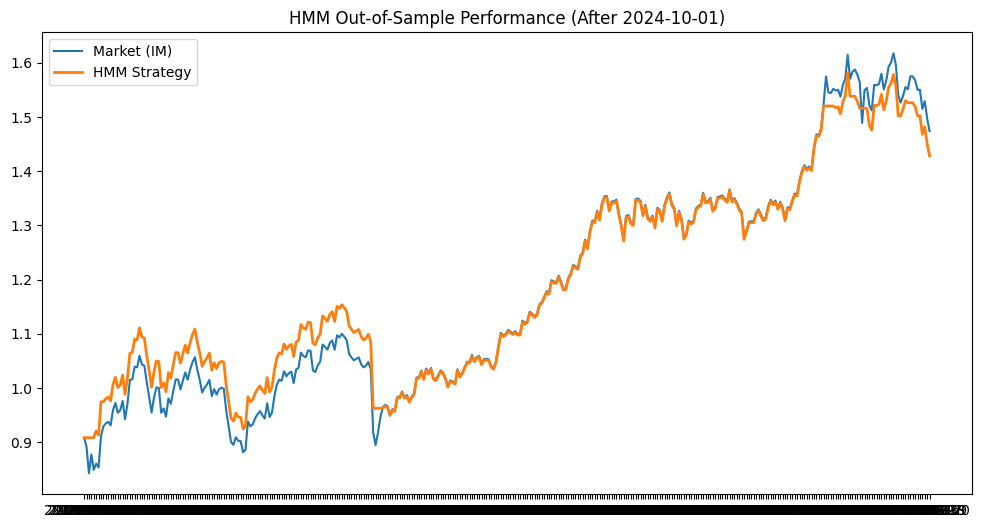

In [136]:
import matplotlib.pyplot as plt
df_test = df_day.loc['2024-10-01':].copy()
# 在测试集上解码状态
df_test['state'] = model.predict(X_test)
test_eval = df_test.groupby('state').agg({
    'f3': ['mean', 'std'],
    'f5': ['mean'],
    'state': 'count'
})
# 做多信号状态
best_state = test_eval[('f3', 'mean')].idxmax()
print(f"识别出的最优做多状态编号为: {best_state}")

# 计算择时收益 (当天收盘知道状态，下一日开盘买入)
# 将状态信号平移一位，避免用到未来数据
df_test['signal'] = (df_test['state'] == best_state).shift(1)
df_test = df_test.dropna()
df_test['strategy_ret'] = df_test['f3'] * df_test['signal']
# 绘制净值曲线
df_test['strategy_ret'] = df_test['strategy_ret'].astype(float)
df_test['f3'] = df_test['f3'].astype(float)

df_test['cum_market'] = np.exp(df_test['f3'].cumsum())
df_test['cum_strategy'] = np.exp(df_test['strategy_ret'].cumsum())
df_test
plt.figure(figsize=(12, 6))
plt.plot(df_test['cum_market'], color = '#1f77b4',  label='Market (IM)')
plt.plot(df_test['cum_strategy'], color= '#ff7f0e',label='HMM Strategy', linewidth=2)
plt.title('HMM Out-of-Sample Performance (After 2024-10-01)')
plt.legend()
plt.show()

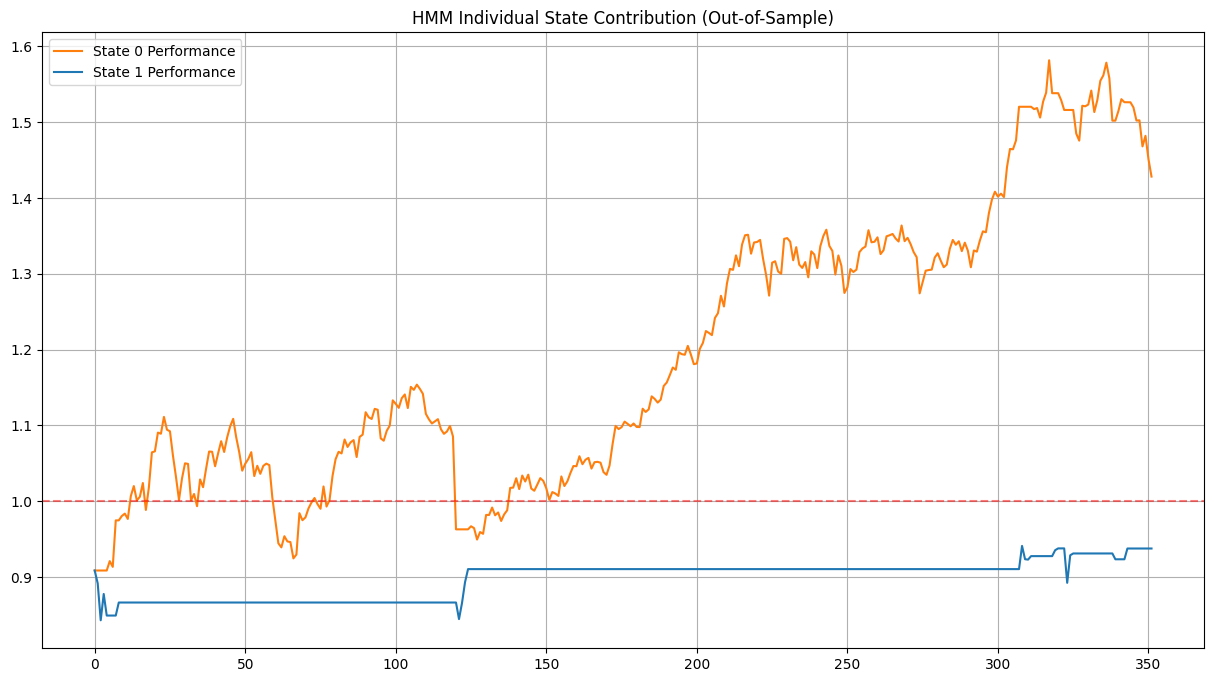

In [137]:
df_test = df_day.loc['2024-10-01':].copy()
df_test['state'] = model.predict(X_test)
test_eval = df_test.groupby('state').agg({
    'f3': ['mean', 'std'],
    'f5': ['mean'],
    'state': 'count'
})
plt.figure(figsize=(15, 8))
colors = ['#ff7f0e', '#1f77b4']
for i in range(model.n_components):
    df_test_sample = df_test
    df_test_sample['signal'] = (df_test['state'] == i).shift(1)
    df_test_sample = df_test_sample.dropna()
    state_ret = (df_test_sample['f3'] * df_test_sample['signal']).astype(float)
    state_ret_values = state_ret.values
    state_ret_values[0] = df_test_sample['f3'].iloc[0]
    state_cum_ret = np.exp(state_ret_values.cumsum())
    plt.plot(state_cum_ret, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
plt.show()